In [3]:
# ==============================================================
# Importación de todas las librerías del proyecto
# ==============================================================

# --- Manejo de datos ---
import pandas as pd
import numpy as np
from pathlib import Path

# --- Visualización ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.express as px
import seaborn as sns

# --- Estadística y preprocesamiento ---
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)


# --- Configuración general de gráficas ---
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

import warnings
warnings.filterwarnings('ignore')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [4]:
# ==============================================================
# Descarga del dataset desde la BTS (fuente oficial)
#
# El dataset proviene del Bureau of Transportation Statistics
# (BTS) del gobierno de EE.UU. Contiene datos de rendimiento
# en tiempo real de aerolíneas comerciales: vuelos, retrasos,
# cancelaciones y causas — de acceso público y gratuito.
#
# Para el proyecto usamos el dataset del año 2022 (Junio a Diciembre)
# en formato ZIP pre-empaquetado por la BTS.
# Descargamos y descomprimimos directamente desde Colab.
# ==============================================================

import zipfile
import io
import requests

# Patrón de URL oficial de la BTS para descargar datos mensuales
base_url = 'https://transtats.bts.gov/PREZIP/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_{year}_{month}.zip'

meses = range(6, 13)  # Enero a Diciembre
year = 2022

dfs = []
print(f'Descargando datos de vuelos del año {year}...')

for mes in meses:
    url = base_url.format(year=year, month=mes)
    print(f'   Mes {mes:02d}/{year}...', end=' ')
    try:
        r = requests.get(url, timeout=60)
        r.raise_for_status()
        with zipfile.ZipFile(io.BytesIO(r.content)) as z:
            csv_name = [f for f in z.namelist() if f.endswith('.csv') and not f.startswith('__')][0]
            with z.open(csv_name) as f:
                df_mes = pd.read_csv(f, low_memory=False)
                dfs.append(df_mes)
        print(f'✓ ({len(df_mes):,} filas)')
    except Exception as e:
        print(f'✗ Error: {e}')

df_raw = pd.concat(dfs, ignore_index=True)
print(f'\n Dataset completo: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')

Descargando datos de vuelos del año 2022...
   Mes 06/2022... ✓ (577,283 filas)
   Mes 07/2022... ✓ (594,957 filas)
   Mes 08/2022... ✓ (589,810 filas)
   Mes 09/2022... ✓ (557,494 filas)
   Mes 10/2022... ✓ (572,287 filas)
   Mes 11/2022... ✗ Error: HTTPSConnectionPool(host='transtats.bts.gov', port=443): Max retries exceeded with url: /PREZIP/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2022_11.zip (Caused by NameResolutionError("HTTPSConnection(host='transtats.bts.gov', port=443): Failed to resolve 'transtats.bts.gov' ([Errno 11001] getaddrinfo failed)"))
   Mes 12/2022... ✓ (557,095 filas)

 Dataset completo: 3,448,926 filas × 110 columnas


In [ ]:
# ==============================================================
# 4 — Selección de variables relevantes
#
# El dataset original tiene ~100 columnas. Selecciono solo
# las necesarias para el proyecto.
# ==============================================================

columnas = [
    # --- FECHA ---
    'FlightDate',          # Fecha del vuelo (tipo: fecha)
    'Month',               # Mes (tipo: ordinal)
    'DayOfWeek',           # Día de la semana 1=Lunes … 7=Dom (tipo: ordinal)

    # --- NOMINALES ---
    'Reporting_Airline',   # Código de aerolínea (tipo: nominal)
    'Origin',              # Aeropuerto de origen (tipo: nominal)
    'Dest',                # Aeropuerto de destino (tipo: nominal)
    'OriginStateName',     # Estado de origen (tipo: nominal)
    'DestStateName',       # Estado de destino (tipo: nominal)

    # --- CONTINUAS ---
    'DepDelay',            # Minutos de retraso en salida (tipo: continua)
    'ArrDelay',            # Minutos de retraso en llegada (tipo: continua)
    'Distance',            # Distancia del vuelo en millas (tipo: continua)
    'AirTime',             # Tiempo en el aire en minutos (tipo: continua)
    'CarrierDelay',        # Retraso atribuido a la aerolínea (tipo: continua)
    'WeatherDelay',        # Retraso por clima (tipo: continua)
    'NASDelay',            # Retraso por sistema aéreo nacional (tipo: continua)

    # --- DISCRETA ---
    'Flight_Number_Reporting_Airline',  # Número de vuelo (tipo: discreta)

    # --- BINARIAS ---
    'Cancelled',           # ¿Fue cancelado? 1=Sí, 0=No (tipo: binaria)
    'Diverted',            # ¿Fue desviado? 1=Sí, 0=No (tipo: binaria)
]

# Filtrar solo columnas que existan en el dataset
columnas_disponibles = [c for c in columnas if c in df_raw.columns]
df = df_raw[columnas_disponibles].copy()

# Crear variable binaria objetivo: ¿Hubo retraso significativo? (>15 min)
# Esto es el estándar de la FAA para considerar un vuelo "retrasado"
df['Delayed'] = (df['ArrDelay'] > 15).astype(int)

print('Variables seleccionadas y sus tipos:')
print(df.dtypes)
print(f'\nForma del dataset: {df.shape}')

Variables seleccionadas y sus tipos:
FlightDate                             str
Month                                int64
DayOfWeek                            int64
Reporting_Airline                      str
Origin                                 str
Dest                                   str
OriginStateName                        str
DestStateName                          str
DepDelay                           float64
Distance                           float64
CarrierDelay                       float64
WeatherDelay                       float64
NASDelay                           float64
Flight_Number_Reporting_Airline      int64
Cancelled                          float64
Diverted                           float64
dtype: object

Forma del dataset: (3448926, 16)


---
# PARTE 1 — Análisis Exploratorio de Datos (EDA)

## 1.1 Contexto del Dataset

**Origen de los datos:** Bureau of Transportation Statistics (BTS), agencia oficial del gobierno de EE.UU. bajo el Departamento de Transporte (DOT). Recopila datos de todas las aerolíneas certificadas que operan en territorio estadounidense.

**Situación problema:** Los retrasos en vuelos generan pérdidas económicas estimadas en miles de millones de dólares anuales y afectan la experiencia de millones de pasajeros. Identificar los factores que determinan si un vuelo se retrasará permite a aerolíneas y aeropuertos tomar decisiones preventivas.

**Preguntas a responder con el EDA:**
1. ¿Qué aerolíneas tienen mayor tasa de retrasos?
2. ¿En qué meses y días de la semana se concentran más retrasos?
3. ¿Cuál es la causa principal de los retrasos?
4. ¿Existe relación entre la distancia del vuelo y el retraso?

## 1.2 Variables del Dataset

| Variable | Tipo | Unidad / Descripción |
|---|---|---|
| `FlightDate` | Fecha | Fecha del vuelo (YYYY-MM-DD) |
| `Month` | Ordinal | Mes (1=Enero … 12=Diciembre) |
| `DayOfWeek` | Ordinal | Día (1=Lunes … 7=Domingo) |
| `Reporting_Airline` | Nominal | Código IATA de la aerolínea |
| `Origin` / `Dest` | Nominal | Código del aeropuerto |
| `OriginStateName` / `DestStateName` | Nominal | Nombre del estado |
| `DepDelay` | Continua | Minutos de retraso en salida |
| `ArrDelay` | Continua | Minutos de retraso en llegada |
| `Distance` | Continua | Millas de distancia del vuelo |
| `AirTime` | Continua | Minutos en el aire |
| `CarrierDelay` / `WeatherDelay` / `NASDelay` | Continua | Minutos de retraso por causa |
| `Flight_Number_Reporting_Airline` | Discreta | Número de vuelo |
| `Cancelled` | Binaria | 0=No cancelado, 1=Cancelado |
| `Diverted` | Binaria | 0=No desviado, 1=Desviado |
| `Delayed` | Binaria | **Variable objetivo**: 1 si ArrDelay > 15 min |

In [ ]:
# ==============================================================
# 6 — Tratamiento Preliminar: Limpieza de datos
#
# Los nulos en las columnas de causa de retraso (CarrierDelay,
# WeatherDelay, etc.) corresponden a vuelos sin retraso (el
# valor real es 0). Las imputamos con 0.
# Eliminamos filas sin ArrDelay ya que es nuestra variable clave.
# ==============================================================

# Convertir FlightDate a tipo datetime
df['FlightDate'] = pd.to_datetime(df['FlightDate'])

# Imputar causas de retraso: NaN → 0 (sin retraso por esa causa)
cols_delay = ['CarrierDelay', 'WeatherDelay', 'NASDelay']
for col in cols_delay:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Eliminar filas donde no hay información de ArrDelay
# (vuelos cancelados no tienen ArrDelay — los excluimos del análisis
# de retraso pero los conservamos para el EDA general)
df_model = df.dropna(subset=['ArrDelay', 'DepDelay', 'Distance', 'AirTime']).copy()

# Recalcular Delayed con el subset limpio
df_model['Delayed'] = (df_model['ArrDelay'] > 15).astype(int)

# Eliminar outliers extremos en ArrDelay
df_model = df_model[df_model['ArrDelay'].between(-120, 480)]

print(f' Dataset después de limpieza: {df_model.shape[0]:,} filas')
print(f'   Nulos restantes: {df_model.isnull().sum().sum()}')

EXPLORACIÓN INICIAL DEL DATASET

 Dimensiones: 3,448,926 filas × 16 columnas

 Primeras 5 filas:


,FlightDate,Month,DayOfWeek,Reporting_Airline,Origin,Dest,OriginStateName,DestStateName,DepDelay,Distance,CarrierDelay,WeatherDelay,NASDelay,Flight_Number_Reporting_Airline,Cancelled,Diverted
0,2022-06-27,6,1,OH,SBN,CLT,Indiana,North Carolina,10.0,534.0,NaN,NaN,NaN,5399,0.0,0.0
1,2022-06-28,6,2,OH,SBN,CLT,Indiana,North Carolina,-4.0,534.0,NaN,NaN,NaN,5399,0.0,0.0
2,2022-06-29,6,3,OH,SBN,CLT,Indiana,North Carolina,-9.0,534.0,NaN,NaN,NaN,5399,0.0,0.0
3,2022-06-30,6,4,OH,SBN,CLT,Indiana,North Carolina,-3.0,534.0,NaN,NaN,NaN,5399,0.0,0.0
4,2022-06-01,6,3,OH,CLT,PIA,North Carolina,Illinois,3.0,607.0,NaN,NaN,NaN,5400,0.0,0.0



 Tipos de datos:


,Tipo
FlightDate,str
Month,int64
DayOfWeek,int64
Reporting_Airline,str
Origin,str
Dest,str
OriginStateName,str
DestStateName,str
DepDelay,float64
Distance,float64



 Valores nulos por columna:


,Nulos,% Nulos
DepDelay,84803,2.46
CarrierDelay,2724348,78.99
WeatherDelay,2724348,78.99
NASDelay,2724348,78.99



 Filas duplicadas: 0


In [13]:
df_cancelled = df[df["Cancelled"] == 1].head(10)
df_cancelled.head(5)

,FlightDate,Month,DayOfWeek,Reporting_Airline,Origin,Dest,OriginStateName,DestStateName,DepDelay,Distance,CarrierDelay,WeatherDelay,NASDelay,Flight_Number_Reporting_Airline,Cancelled,Diverted
175,2022-06-16,6,4,OH,CLT,CHA,North Carolina,Tennessee,NaN,241.0,0.0,0.0,0.0,5406,1.0,0.0
263,2022-06-17,6,5,OH,CRW,CLT,West Virginia,North Carolina,NaN,221.0,0.0,0.0,0.0,5408,1.0,0.0
304,2022-06-30,6,4,OH,BTV,DCA,Vermont,Virginia,NaN,437.0,0.0,0.0,0.0,5409,1.0,0.0
316,2022-06-14,6,2,OH,DCA,BTV,Virginia,Vermont,NaN,437.0,0.0,0.0,0.0,5409,1.0,0.0
402,2022-06-14,6,2,OH,DCA,TYS,Virginia,Tennessee,NaN,437.0,0.0,0.0,0.0,5412,1.0,0.0


In [ ]:
# ==============================================================
# Tratamiento Preliminar: Limpieza de datos
#
# Los nulos en las columnas de causa de retraso (CarrierDelay,
# WeatherDelay, etc.) corresponden a vuelos sin retraso (el
# valor real es 0). Las imputamos con 0.
# Eliminamos filas sin ArrDelay ya que es nuestra variable clave.
# ==============================================================

# Convertir FlightDate a tipo datetime
df['FlightDate'] = pd.to_datetime(df['FlightDate'])

# Imputar causas de retraso: NaN → 0 (sin retraso por esa causa)
cols_delay = ['CarrierDelay', 'WeatherDelay', 'NASDelay']
for col in cols_delay:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Eliminar filas donde no hay información de ArrDelay
# (vuelos cancelados no tienen ArrDelay — los excluimos del análisis
# de retraso pero los conservamos para el EDA general)
df_model = df.dropna(subset=['ArrDelay', 'DepDelay', 'Distance', 'AirTime']).copy()

# Recalcular Delayed con el subset limpio
df_model['Delayed'] = (df_model['ArrDelay'] > 15).astype(int)

# Eliminar outliers extremos en ArrDelay (más de 8 horas = 480 min)
# Estos suelen ser errores de registro o eventos excepcionales
df_model = df_model[df_model['ArrDelay'].between(-120, 480)]

print(f' Dataset después de limpieza: {df_model.shape[0]:,} filas')
print(f'   Nulos restantes: {df_model.isnull().sum().sum()}')

NameError: name 'df_model' is not defined

In [7]:
# ==============================================================
# Estadísticas descriptivas de variables continuas
# El método .describe() nos da media, desviación estándar,
# cuartiles y valores extremos de cada variable numérica.
# ==============================================================

print(' Estadísticas descriptivas — variables numéricas:')
cols_num = ['ArrDelay', 'DepDelay', 'Distance', 'AirTime', 'CarrierDelay', 'WeatherDelay']
cols_num = [c for c in cols_num if c in df_model.columns]
display(df_model[cols_num].describe().round(2))

 Estadísticas descriptivas — variables numéricas:


,ArrDelay,DepDelay,Distance,AirTime,CarrierDelay,WeatherDelay
count,3885432.00,3885432.00,3885432.00,3885432.00,3885432.00,3885432.00
mean,5.93,11.27,814.08,111.93,4.67,0.68
std,40.59,38.10,598.74,70.03,21.72,9.25
min,-99.00,-96.00,31.00,8.00,0.00,0.00
25%,-14.00,-5.00,379.00,61.00,0.00,0.00
50%,-5.00,-1.00,653.00,94.00,0.00,0.00
75%,10.00,10.00,1047.00,141.00,0.00,0.00
max,480.00,519.00,5095.00,697.00,480.00,480.00


In [8]:
# ==============================================================
# Descripción de variables categóricas
# Contamos categorías únicas y las más frecuentes.
# ==============================================================

print(' Variables categóricas — valores únicos y más frecuentes:\n')
cols_cat = ['Reporting_Airline', 'Origin', 'Dest', 'OriginStateName']
cols_cat = [c for c in cols_cat if c in df_model.columns]

for col in cols_cat:
    n_unique = df_model[col].nunique()
    top3 = df_model[col].value_counts().head(3).to_dict()
    print(f'  {col}: {n_unique} categorías únicas')
    print(f'    Top 3: {top3}\n')

 Variables categóricas — valores únicos y más frecuentes:

  Reporting_Airline: 17 categorías únicas
    Top 3: {'WN': 774653, 'DL': 526955, 'AA': 511934}

  Origin: 368 categorías únicas
    Top 3: {'ATL': 185429, 'DEN': 161360, 'DFW': 160110}

  Dest: 369 categorías únicas
    Top 3: {'ATL': 185406, 'DEN': 160908, 'DFW': 159479}

  OriginStateName: 53 categorías únicas
    Top 3: {'California': 434388, 'Texas': 410696, 'Florida': 312124}



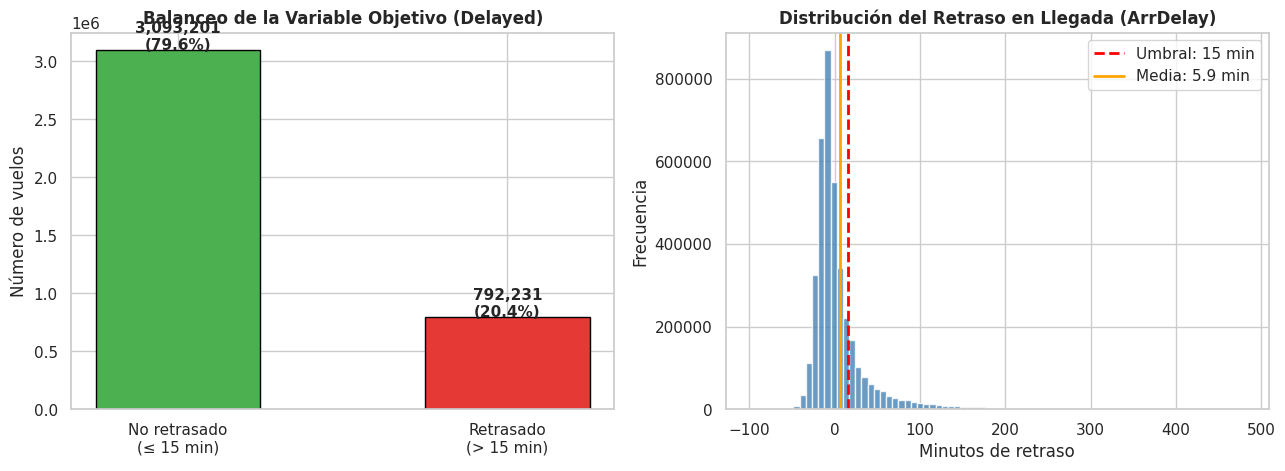


Prueba estadística sobre la variable objetivo:
  Media de ArrDelay: 5.93 min
  Mediana de ArrDelay: -5.00 min
  Proporción de vuelos retrasados: 20.4%

  Test de normalidad (KS) sobre ArrDelay:
  Estadístico=0.5567, p-valor=0.000000
  Conclusión: La distribución NO es normal (p < 0.05)


In [9]:
# ==============================================================
# Variable objetivo: análisis del balanceo
#
# Antes de modelar, es crucial entender si la variable binaria
# objetivo está balanceada o no. Un desbalanceo severo puede
# requerir técnicas especiales (oversampling, pesos de clase).
# ==============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Gráfica de barras: conteo de vuelos retrasados vs no retrasados ---
conteo = df_model['Delayed'].value_counts()
etiquetas = ['No retrasado\n(≤ 15 min)', 'Retrasado\n(> 15 min)']
colores = ['#4CAF50', '#E53935']
axes[0].bar(etiquetas, conteo.values, color=colores, edgecolor='black', width=0.5)
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 5000, f'{v:,}\n({v/len(df_model)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Balanceo de la Variable Objetivo (Delayed)', fontweight='bold')
axes[0].set_ylabel('Número de vuelos')

# --- Distribución del retraso en llegada ---
axes[1].hist(df_model['ArrDelay'], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(15, color='red', linestyle='--', linewidth=2, label='Umbral: 15 min')
axes[1].axvline(df_model['ArrDelay'].mean(), color='orange', linestyle='-', linewidth=2,
                label=f'Media: {df_model["ArrDelay"].mean():.1f} min')
axes[1].set_title('Distribución del Retraso en Llegada (ArrDelay)', fontweight='bold')
axes[1].set_xlabel('Minutos de retraso')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nPrueba estadística sobre la variable objetivo:')
print(f'  Media de ArrDelay: {df_model["ArrDelay"].mean():.2f} min')
print(f'  Mediana de ArrDelay: {df_model["ArrDelay"].median():.2f} min')
print(f'  Proporción de vuelos retrasados: {df_model["Delayed"].mean()*100:.1f}%')

# Prueba de normalidad (Shapiro en muestra pequeña, KS para datasets grandes)
stat, p = stats.kstest(df_model['ArrDelay'].sample(1000, random_state=42), 'norm')
print(f'\n  Test de normalidad (KS) sobre ArrDelay:')
print(f'  Estadístico={stat:.4f}, p-valor={p:.6f}')
print(f'  Conclusión: La distribución NO es normal (p < 0.05)' if p < 0.05 else 'es normal (p >= 0.05)')

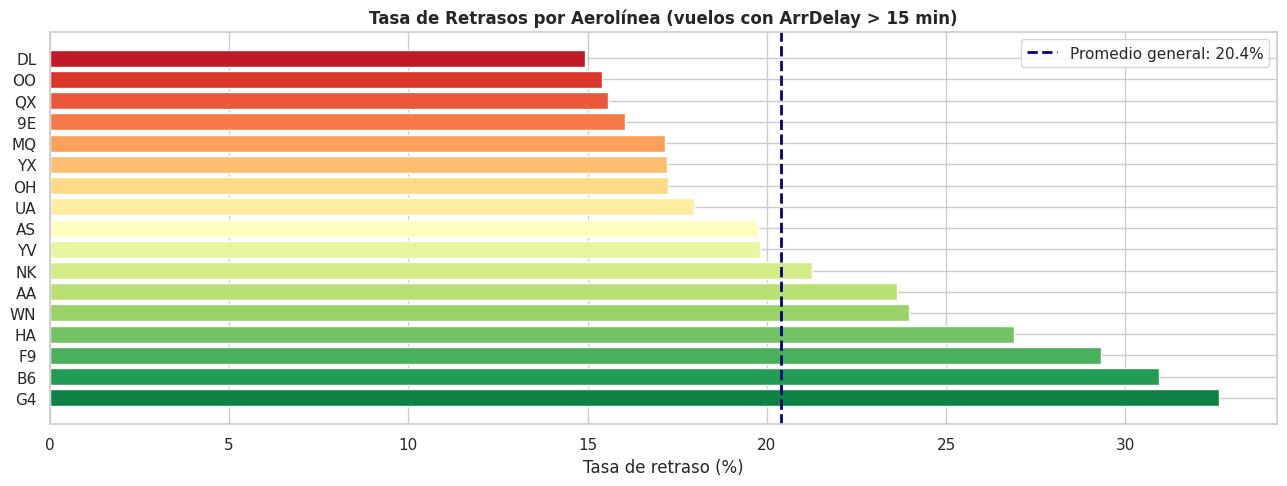

In [10]:
# ==============================================================
# CELDA 10 — EDA: Retrasos por aerolínea
# Calculamos la tasa de retraso promedio por aerolínea para
# identificar cuáles tienen peor desempeño.
# ==============================================================

tasa_aerolinea = (
    df_model.groupby('Reporting_Airline')['Delayed']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Tasa_Retraso', 'count': 'N_Vuelos'})
    .query('N_Vuelos > 1000')  # Solo aerolíneas con suficiente volumen
    .sort_values('Tasa_Retraso', ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.barh(tasa_aerolinea['Reporting_Airline'], tasa_aerolinea['Tasa_Retraso'] * 100,
               color=sns.color_palette('RdYlGn_r', len(tasa_aerolinea)))
ax.axvline(df_model['Delayed'].mean() * 100, color='navy', linestyle='--',
           linewidth=2, label=f'Promedio general: {df_model["Delayed"].mean()*100:.1f}%')
ax.set_xlabel('Tasa de retraso (%)')
ax.set_title('Tasa de Retrasos por Aerolínea (vuelos con ArrDelay > 15 min)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

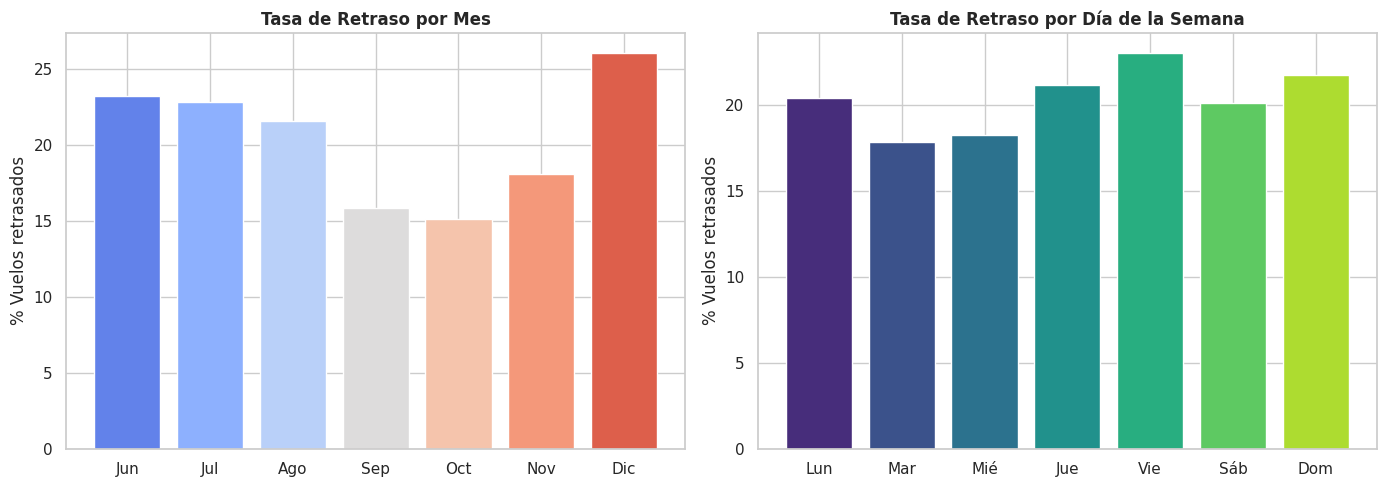

In [11]:
# ==============================================================
# EDA: Retrasos por mes y día de la semana
# Identificamos patrones temporales estacionales y semanales.
# ==============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Por mes ---
mes_labels = ['Jun','Jul','Ago','Sep','Oct','Nov','Dic']
tasa_mes = df_model.groupby('Month')['Delayed'].mean() * 100
axes[0].bar(tasa_mes.index, tasa_mes.values, color=sns.color_palette('coolwarm', 7))
axes[0].set_xticks(range(6, 13))
axes[0].set_xticklabels(mes_labels)
axes[0].set_title('Tasa de Retraso por Mes', fontweight='bold')
axes[0].set_ylabel('% Vuelos retrasados')

# --- Por día de la semana ---
dia_labels = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
tasa_dia = df_model.groupby('DayOfWeek')['Delayed'].mean() * 100
axes[1].bar(tasa_dia.index, tasa_dia.values, color=sns.color_palette('viridis', 7))
axes[1].set_xticks(range(1, 8))
axes[1].set_xticklabels(dia_labels)
axes[1].set_title('Tasa de Retraso por Día de la Semana', fontweight='bold')
axes[1].set_ylabel('% Vuelos retrasados')

plt.tight_layout()
plt.show()

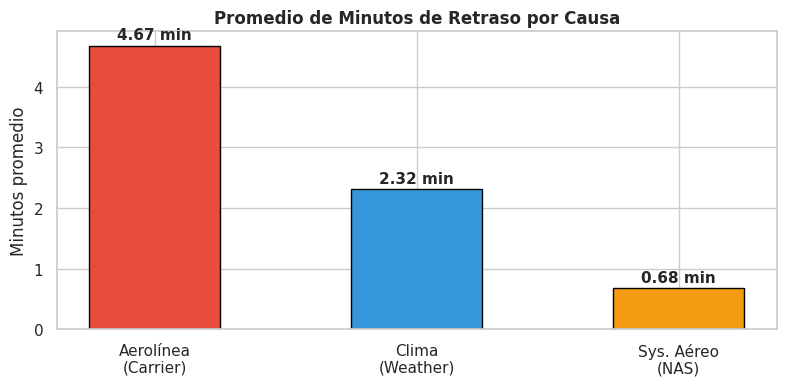

In [12]:
# ==============================================================
# EDA: Causas de retraso
# Comparamos la magnitud promedio de cada tipo de causa.
# ==============================================================

causas = ['CarrierDelay', 'WeatherDelay', 'NASDelay']
causas = [c for c in causas if c in df_model.columns]
promedios = df_model[causas].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(promedios.index, promedios.values,
       color=['#e74c3c', '#3498db', '#f39c12'][:len(causas)],
       edgecolor='black', width=0.5)
ax.set_title('Promedio de Minutos de Retraso por Causa', fontweight='bold')
ax.set_ylabel('Minutos promedio')
ax.set_xticklabels(['Aerolínea\n(Carrier)', 'Clima\n(Weather)', 'Sys. Aéreo\n(NAS)'][:len(causas)])
for i, v in enumerate(promedios.values):
    ax.text(i, v + 0.1, f'{v:.2f} min', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

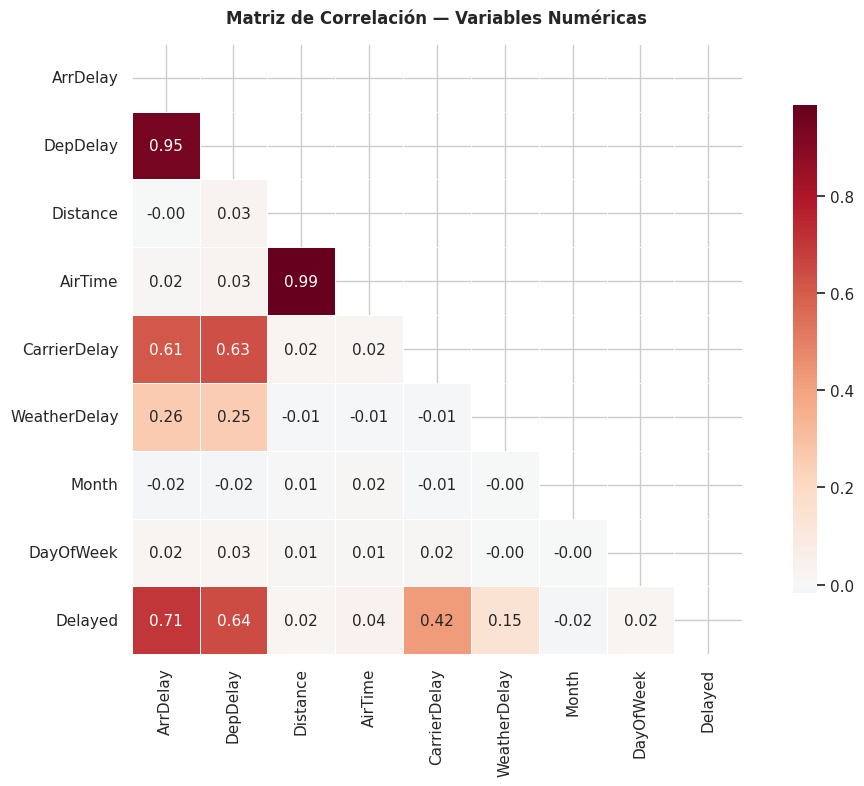


 Correlaciones con la variable objetivo (Delayed):


,Correlación
ArrDelay,0.706
DepDelay,0.639
CarrierDelay,0.421
WeatherDelay,0.146
AirTime,0.041
Distance,0.024
DayOfWeek,0.024
Month,-0.015


In [13]:
# ==============================================================
# EDA: Asociaciones entre variables (correlación)
#
# Calculamos la matriz de correlación de Pearson entre las
# variables numéricas para detectar multicolinealidad y
# asociaciones útiles para el modelo.
# ==============================================================

cols_corr = ['ArrDelay', 'DepDelay', 'Distance', 'AirTime', 'CarrierDelay',
             'WeatherDelay', 'Month', 'DayOfWeek', 'Delayed']
cols_corr = [c for c in cols_corr if c in df_model.columns]

corr_matrix = df_model[cols_corr].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Solo triángulo inferior
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlación — Variables Numéricas', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('\n Correlaciones con la variable objetivo (Delayed):')
display(corr_matrix['Delayed'].drop('Delayed').sort_values(ascending=False).to_frame('Correlación').round(3))

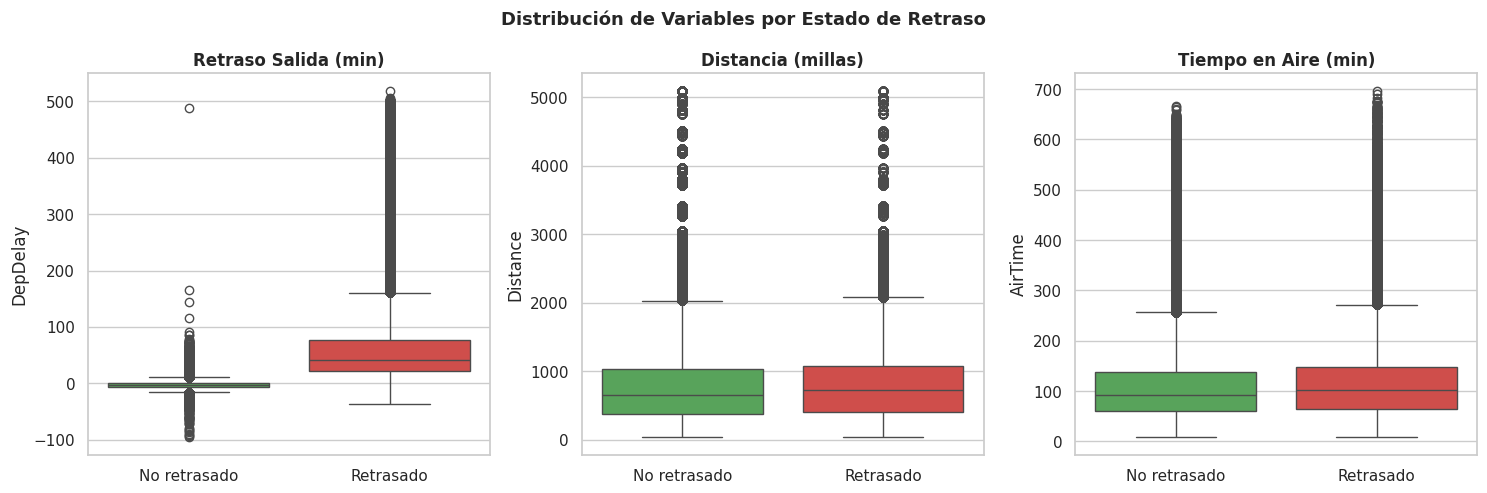

In [14]:
# ==============================================================
# EDA: Boxplots comparativos
# Comparamos la distribución de variables continuas entre
# vuelos retrasados y no retrasados.
# ==============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

vars_box = ['DepDelay', 'Distance', 'AirTime']
labels_box = ['Retraso Salida (min)', 'Distancia (millas)', 'Tiempo en Aire (min)']

for ax, var, label in zip(axes, vars_box, labels_box):
    if var in df_model.columns:
        # Mapeamos Delayed (0/1 entero) a etiquetas de texto para evitar
        # el error de tipos con el diccionario de colores del palette
        df_plot = df_model[[var, 'Delayed']].copy()
        df_plot['Estado'] = df_plot['Delayed'].map({0: 'No retrasado', 1: 'Retrasado'})
        sns.boxplot(data=df_plot, x='Estado', y=var, ax=ax,
                    palette={'No retrasado': '#4CAF50', 'Retrasado': '#E53935'},
                    order=['No retrasado', 'Retrasado'])
        ax.set_title(label, fontweight='bold')
        ax.set_xlabel('')

plt.suptitle('Distribución de Variables por Estado de Retraso', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
# PARTE 2 — MODELO

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

In [ ]:
datos = ['DepDelay', 'Distance', 'CarrierDelay','WeatherDelay','NASDelay','Reporting_Airline','Origin','Dest','OriginStateName','DestStateName','Cancelled']

In [ ]:
target_col = 'Cancelled'